 PROJE KONUSU : Dinlenen Müzik Türlerinin Ruh Hali ve Stres Seviyesi Üzerindeki Etkisinin Makine Öğrenmesi ile Analizi

 ÖĞRENCİ NO - AD SOYAD:
*   23100011055-Elif Sultan TÜRKYILMAZ
*   23100011027-Rümeysa ÇIKRIK
*   22100011063-Irmak KAHRAMAN
DERSİN SORUMLUSU :
*  Dr. Öğr. Üyesi AYŞE MERVE ACILAR

 Bu kod dosyasında, Music & Mental Health Survey veri seti kullanılarak bireylerin müzik dinleme alışkanlıkları ile ruh sağlığı (anksiyete, depresyon vb.) arasındaki ilişkiler analiz edilmektedir.
 Amaç:
 Müzik türlerinin bireylerin ruh hali ve stres seviyeleri üzerindeki
 etkisini analiz etmek ve bu etkileri makine öğrenmesi ile tahmin etmektir.

In [17]:
#drive bağlanma
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Aşağıda, Music & Mental Health Survey veri seti Python ortamında yüklenmiş ve veri setinin temel yapısı incelenmiştir. Veri setindeki toplam kayıt ve özellik sayısı belirlenerek genel büyüklüğü analiz edilmiştir. Ayrıca, sayısal değişkenlere ait ortalama, minimum, maksimum ve standart sapma gibi istatistiksel değerler describe() fonksiyonu kullanılarak elde edilmiştir. Bu süreç, veri setinin dağılımını anlamak ve sonraki analiz adımları için temel oluşturmak amacıyla gerçekleştirilmiştir.


In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Veriyi oku
df = pd.read_csv('/content/drive/MyDrive/mxmh_survey_results.csv')

# Materyal bölümü için temel istatistikler [cite: 324]
print(f"Kayıt Sayısı: {df.shape[0]}")
print(f"Özellik Sayısı: {df.shape[1]}")
display(df.describe()) # İstatistiksel özet [cite: 324]

Kayıt Sayısı: 736
Özellik Sayısı: 33


,Age,Hours per day,BPM,Anxiety,Depression,Insomnia,OCD
count,735.000000,736.000000,6.290000e+02,736.000000,736.000000,736.000000,736.000000
mean,25.206803,3.572758,1.589948e+06,5.837636,4.796196,3.738451,2.637228
std,12.054970,3.028199,3.987261e+07,2.793054,3.028870,3.088689,2.842017
min,10.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,18.000000,2.000000,1.000000e+02,4.000000,2.000000,1.000000,0.000000
50%,21.000000,3.000000,1.200000e+02,6.000000,5.000000,3.000000,2.000000
75%,28.000000,5.000000,1.440000e+02,8.000000,7.000000,6.000000,5.000000
max,89.000000,24.000000,1.000000e+09,10.000000,10.000000,10.000000,10.000000


Aşağıda , veri setinde yer alan ruh sağlığı değişkenlerinin (Anxiety, Depression, Insomnia, OCD) dağılımı incelenmiştir. Her bir değişken için histogram grafikleri oluşturularak katılımcıların bu skorlar üzerindeki yoğunlukları görselleştirilmiştir. Elde edilen grafikler sayesinde, ruh sağlığı skorlarının veri seti içerisindeki genel dağılımı ve eğilimleri analiz edilerek veri hakkında ön bilgi edinilmiştir.

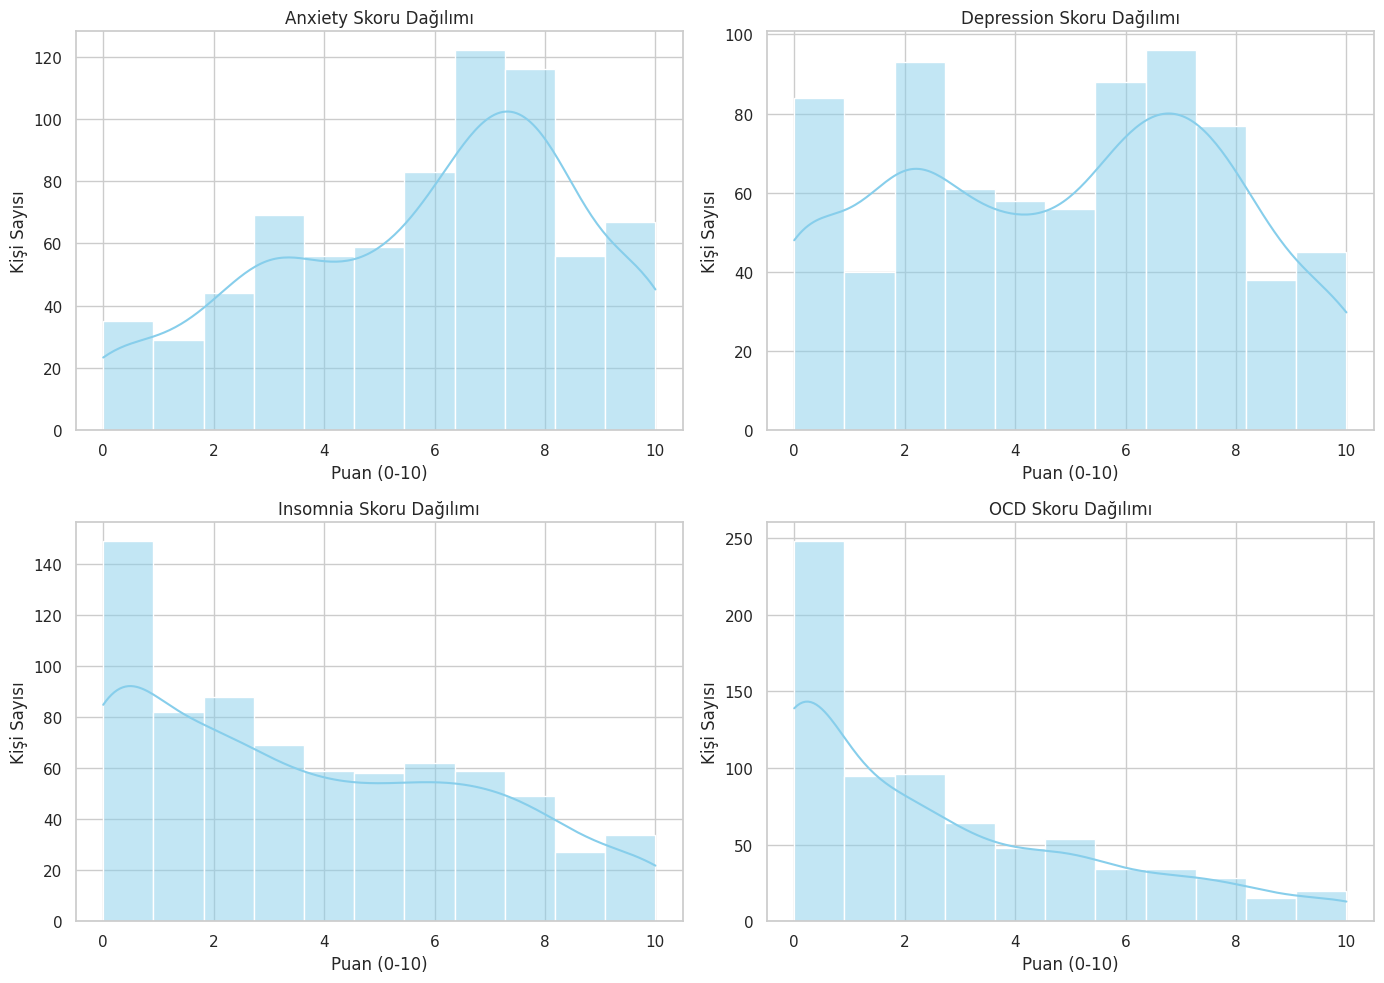

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Veriyi Yükle
df = pd.read_csv('/content/drive/MyDrive/mxmh_survey_results.csv')

# --- ÖZELLİK SEÇİMİ ---
mental_health_cols = ['Anxiety', 'Depression', 'Insomnia', 'OCD']
music_habits = ['Age', 'Hours per day', 'BPM']

# --- GÖRSELLEŞTİRME ---

# A. Ruh Sağlığı Skor Dağılımları
plt.figure(figsize=(14, 10))
for i, col in enumerate(mental_health_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], bins=11, kde=True, color='skyblue')
    plt.title(f'{col} Skoru Dağılımı')
    plt.xlabel('Puan (0-10)')
    plt.ylabel('Kişi Sayısı')
plt.tight_layout()
plt.show()


Aşağıda veri seti üzerinde kapsamlı bir veri ön işleme süreci gerçekleştirilmiştir. Öncelikle eksik veriler ve aykırı değerler görselleştirilerek analiz edilmiş, ardından hatalı ve mantık dışı girişler (BPM, yaş ve günlük dinleme süresi) temizlenmiştir. Eksik değerler sayısal değişkenlerde medyan, kategorik değişkenlerde ise mod yöntemi ile doldurulmuştur. Temizleme işlemleri öncesi ve sonrası durum karşılaştırmalı olarak görselleştirilmiştir.

Ardından, temizlenmiş veri seti kullanılarak keşifçi veri analizi (EDA) yapılmış; katılımcı profili, müzik türleri ile ruh sağlığı değişkenleri arasındaki ilişkiler çeşitli grafikler (histogram, barplot, scatterplot, lineplot ve korelasyon ısı haritası) ile incelenmiştir. Bu analizler sayesinde değişkenler arasındaki eğilimler ve ilişkiler daha net bir şekilde ortaya konulmuştur.

✅ Veri başarıyla yüklendi!


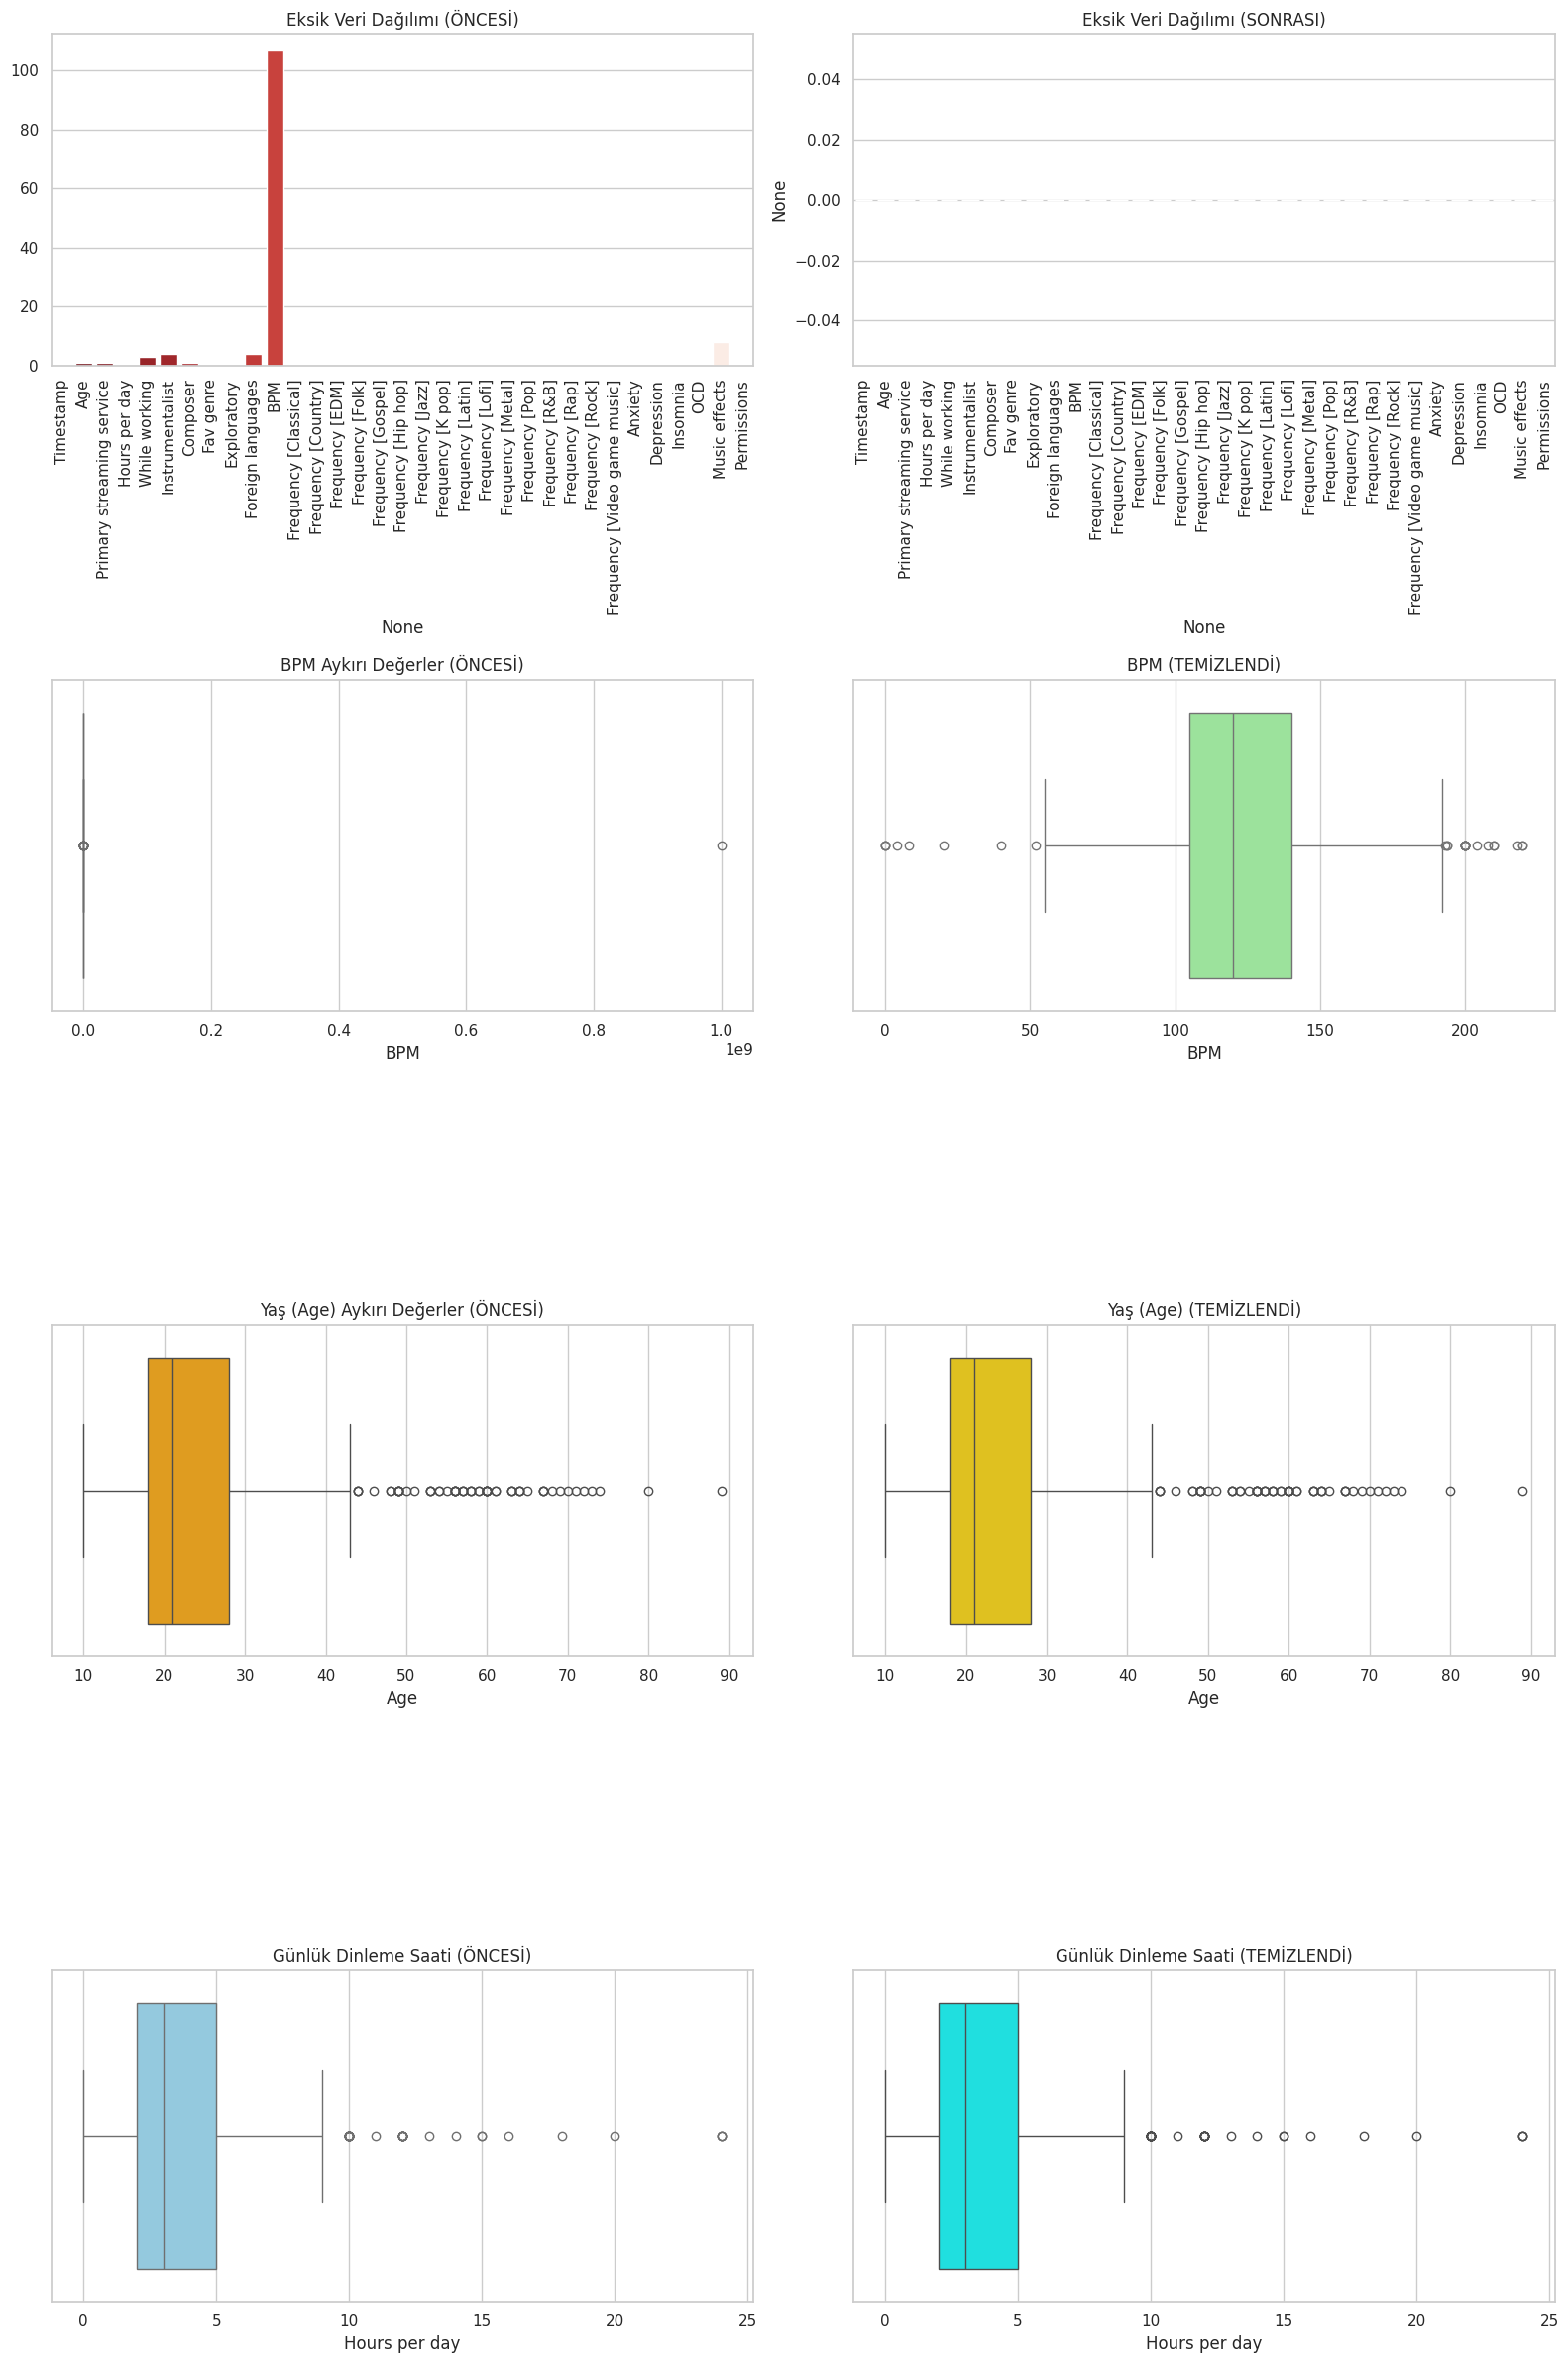

✅ Tüm eksik ve aykırı değerler temizlendi. İstatistiksel analizlere geçiliyor...


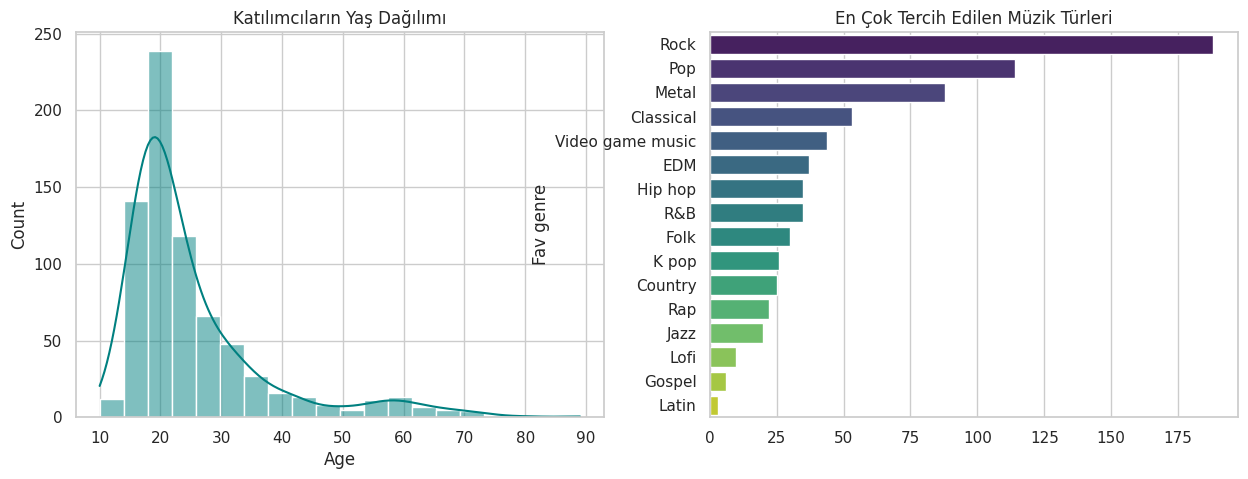

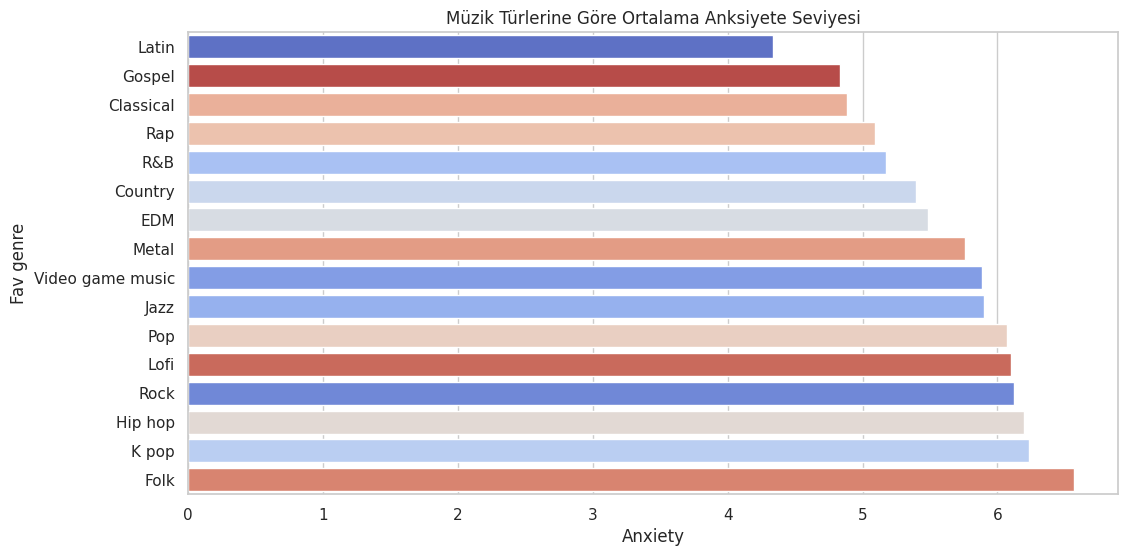

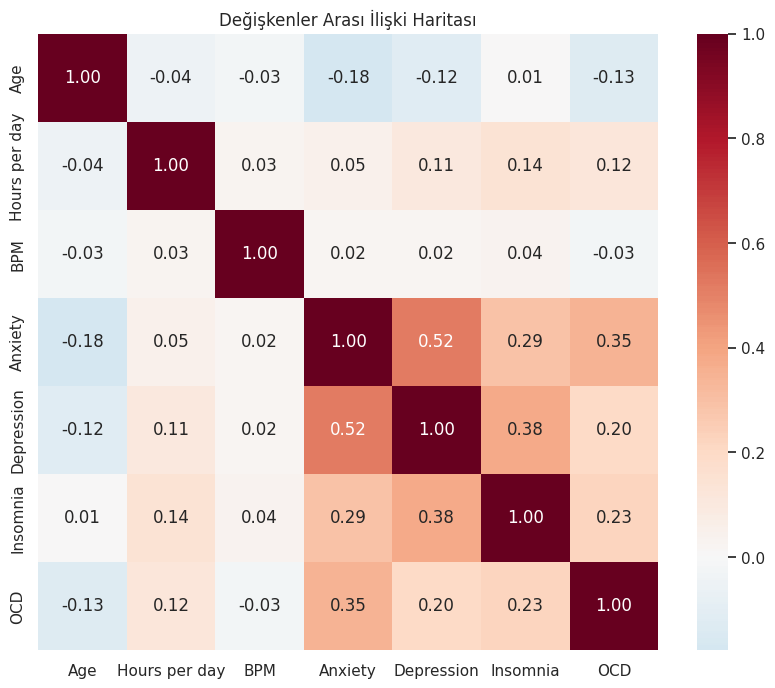

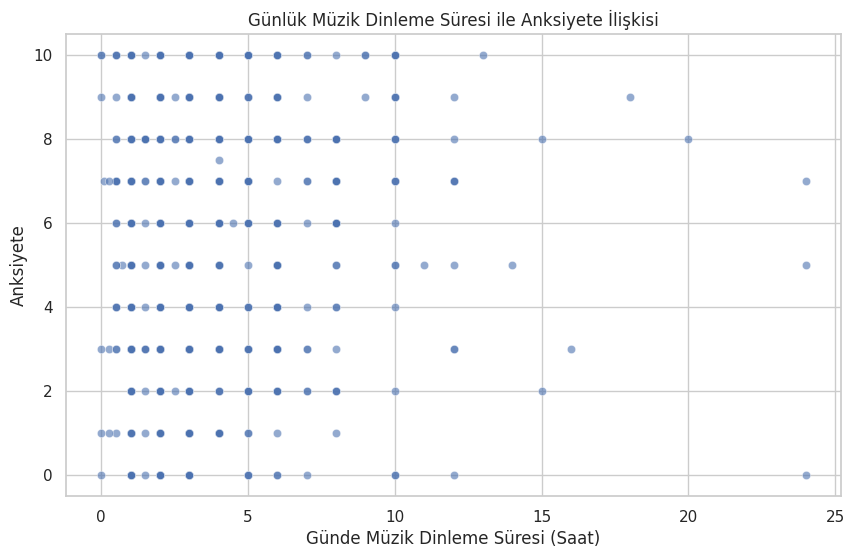

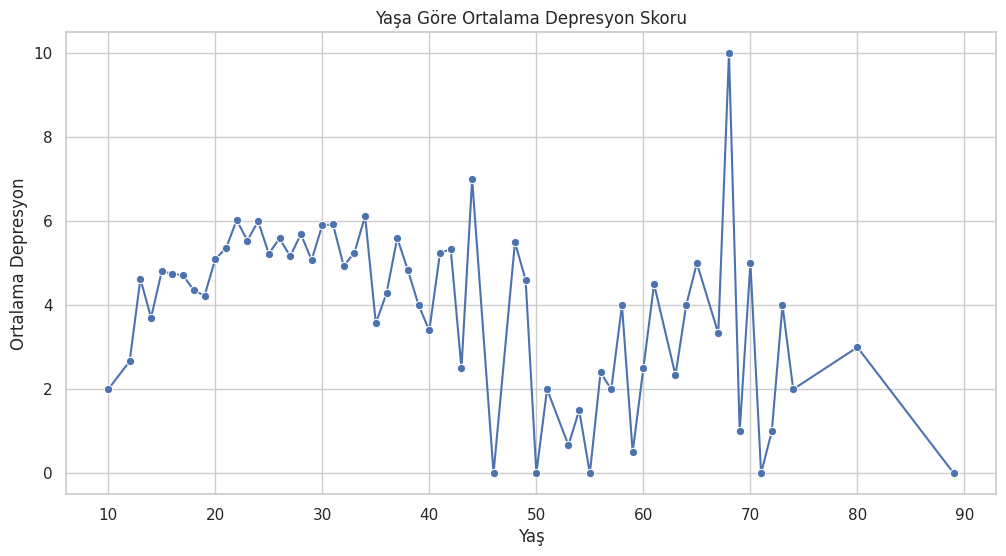

🎯 Veri ön işleme ve keşifçi veri analizi (EDA) başarıyla tamamlandı!


In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Tema ayarları
sns.set_theme(style="whitegrid")

# --- 1. VERİ SETİNİ YÜKLEME ---
try:
    df = pd.read_csv('/content/drive/MyDrive/mxmh_survey_results.csv')
    print("✅ Veri başarıyla yüklendi!")
except FileNotFoundError:
    print("❌ Hata: Dosya bulunamadı. Lütfen yolu kontrol edin.")

# --- 2. VERİ ÖN İŞLEME: EKSİK VE AYKIRI VERİ ANALİZİ (GÖRSELLEŞTİRME) ---
# 4 Satır (Eksik Veri, BPM, Yaş, Saat) x 2 Sütun (Önce-Sonra)
fig, axes = plt.subplots(4, 2, figsize=(16, 24))

# --- [A] TEMİZLEME ÖNCESİ DURUM ---
# 1. Eksik Veri
missing_before = df.isnull().sum()
sns.barplot(x=missing_before.index, y=missing_before.values, ax=axes[0, 0], palette='Reds_r', hue=missing_before.index, legend=False)
axes[0, 0].set_title('Eksik Veri Dağılımı (ÖNCESİ)')
axes[0, 0].tick_params(axis='x', rotation=90)

# 2. BPM Aykırı Değerler
sns.boxplot(x=df['BPM'], ax=axes[1, 0], color='salmon')
axes[1, 0].set_title('BPM Aykırı Değerler (ÖNCESİ)')

# 3. Yaş Aykırı Değerler
sns.boxplot(x=df['Age'], ax=axes[2, 0], color='orange')
axes[2, 0].set_title('Yaş (Age) Aykırı Değerler (ÖNCESİ)')

# 4. Saat Aykırı Değerler
sns.boxplot(x=df['Hours per day'], ax=axes[3, 0], color='skyblue')
axes[3, 0].set_title('Günlük Dinleme Saati (ÖNCESİ)')


# --- [B] TEMİZLEME İŞLEMLERİ (Preprocessing) ---
df_cleaned = df.copy()

# 1. BPM Temizliği: 500+ hatalı değerleri temizleme
df_cleaned.loc[df_cleaned['BPM'] > 500, 'BPM'] = np.nan

# 2. Yaş Temizliği: 10 altı ve 90 üstü hatalı/uç girişleri temizleme
df_cleaned.loc[(df_cleaned['Age'] > 90) | (df_cleaned['Age'] < 10), 'Age'] = np.nan

# 3. Saat Temizliği: 24 saati aşan (mantık dışı) girişleri temizleme
df_cleaned.loc[df_cleaned['Hours per day'] > 24, 'Hours per day'] = np.nan

# 4. Boşlukları Doldurma (Sayısal: Medyan, Kategorik: Mod)
for col in df_cleaned.columns:
    if df_cleaned[col].dtype == 'object':
        df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mode()[0])
    else:
        df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())


# --- [C] TEMİZLEME SONRASI DURUM ---
# 1. Eksik Veri
sns.barplot(x=df_cleaned.columns, y=df_cleaned.isnull().sum(), ax=axes[0, 1], color='green')
axes[0, 1].set_title('Eksik Veri Dağılımı (SONRASI)')
axes[0, 1].tick_params(axis='x', rotation=90)

# 2. BPM
sns.boxplot(x=df_cleaned['BPM'], ax=axes[1, 1], color='lightgreen')
axes[1, 1].set_title('BPM (TEMİZLENDİ)')

# 3. Yaş
sns.boxplot(x=df_cleaned['Age'], ax=axes[2, 1], color='gold')
axes[2, 1].set_title('Yaş (Age) (TEMİZLENDİ)')

# 4. Saat
sns.boxplot(x=df_cleaned['Hours per day'], ax=axes[3, 1], color='cyan')
axes[3, 1].set_title('Günlük Dinleme Saati (TEMİZLENDİ)')

plt.tight_layout()
plt.show()

print("✅ Tüm eksik ve aykırı değerler temizlendi. İstatistiksel analizlere geçiliyor...")

# --- 3. TÜM DETAYLI GÖRSELLEŞTİRMELER (TEMİZLENMİŞ VERİ İLE) ---

# A. KATILIMCI PROFİLİ
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_cleaned['Age'], bins=20, kde=True, color='teal')
plt.title('Katılımcıların Yaş Dağılımı')

plt.subplot(1, 2, 2)
genre_counts = df_cleaned['Fav genre'].value_counts()
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='viridis', hue=genre_counts.index, legend=False)
plt.title('En Çok Tercih Edilen Müzik Türleri')
plt.show()

# B. ARAŞTIRMA SORULARI
# Müzik Türü ve Anksiyete
plt.figure(figsize=(12, 6))
genre_order = df_cleaned.groupby('Fav genre')['Anxiety'].mean().sort_values().index
sns.barplot(data=df_cleaned, x='Anxiety', y='Fav genre', order=genre_order, palette='coolwarm', errorbar=None, hue='Fav genre', legend=False)
plt.title('Müzik Türlerine Göre Ortalama Anksiyete Seviyesi')
plt.show()

# Korelasyon Isı Haritası
plt.figure(figsize=(10, 8))
selected_cols = ['Age', 'Hours per day', 'BPM', 'Anxiety', 'Depression', 'Insomnia', 'OCD']
sns.heatmap(df_cleaned[selected_cols].corr(), annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title('Değişkenler Arası İlişki Haritası')
plt.show()

# EK 2: Scatterplot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_cleaned, x='Hours per day', y='Anxiety', alpha=0.6)
plt.title('Günlük Müzik Dinleme Süresi ile Anksiyete İlişkisi')
plt.xlabel('Günde Müzik Dinleme Süresi (Saat)')
plt.ylabel('Anksiyete')
plt.show()

# EK 4: Lineplot
age_dep = df_cleaned.groupby('Age')['Depression'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=age_dep, x='Age', y='Depression', marker='o')
plt.title('Yaşa Göre Ortalama Depresyon Skoru')
plt.xlabel('Yaş')
plt.ylabel('Ortalama Depresyon')
plt.show()



print("🎯 Veri ön işleme ve keşifçi veri analizi (EDA) başarıyla tamamlandı!")

Aşağıda, veri seti üzerinde kapsamlı bir keşifçi veri analizi (EDA) gerçekleştirilmiştir. Temizlenmiş veri seti kullanılarak sayısal değişkenler arasındaki ilişkiler pairplot grafiği ile incelenmiş, anksiyete ve depresyon değişkenlerinin dağılımları histogram ve KDE grafikleri ile analiz edilmiştir. Ayrıca, bu iki psikolojik değişkenin yoğunluk dağılımları karşılaştırmalı olarak değerlendirilmiştir.

Müziğin bireyler üzerindeki etkisini daha detaylı incelemek amacıyla, “Music effects” kategorisine göre anksiyete ve depresyon skorlarının dağılımı violin plot ve boxplot grafikleri ile görselleştirilmiştir. Bunun yanı sıra, günlük müzik dinleme süresi ile anksiyete ve depresyon arasındaki ilişki lmplot grafikleri ile analiz edilerek olası doğrusal eğilimler gözlemlenmiştir.

Değişkenler arasındaki genel ilişkiyi ortaya koymak amacıyla korelasyon matrisi oluşturulmuş, son olarak katılımcıların en çok tercih ettiği müzik türleri frekans grafiği ile gösterilmiştir. Bu görselleştirmeler sayesinde veri setindeki temel eğilimler, dağılımlar ve değişkenler arası ilişkiler daha net bir şekilde ortaya konulmuştur.

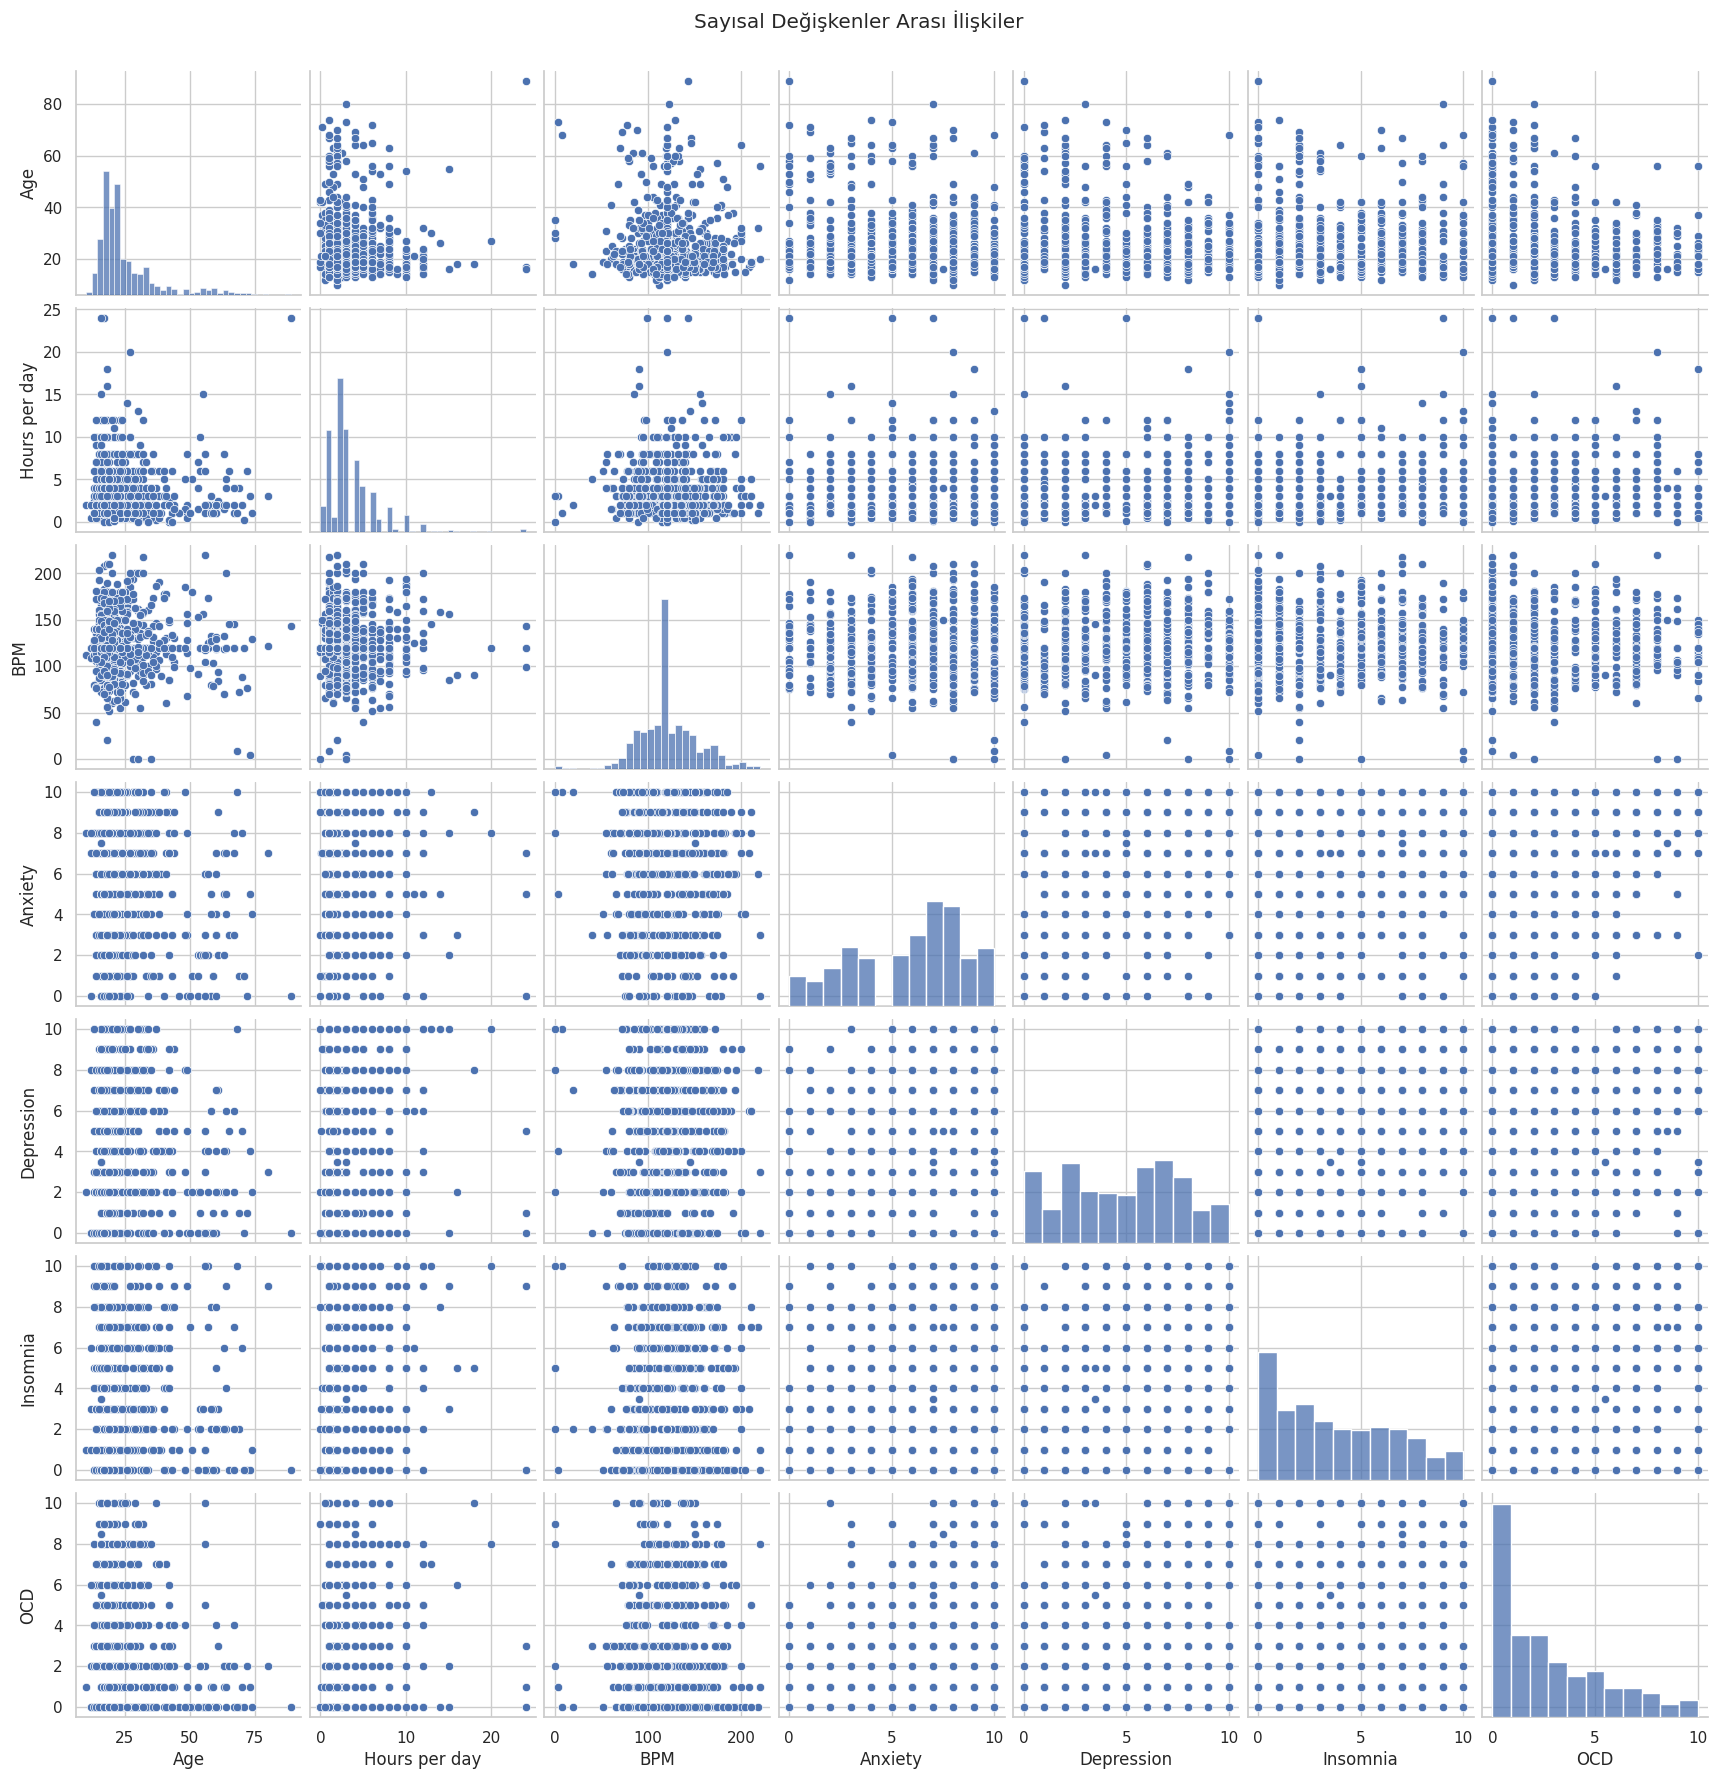

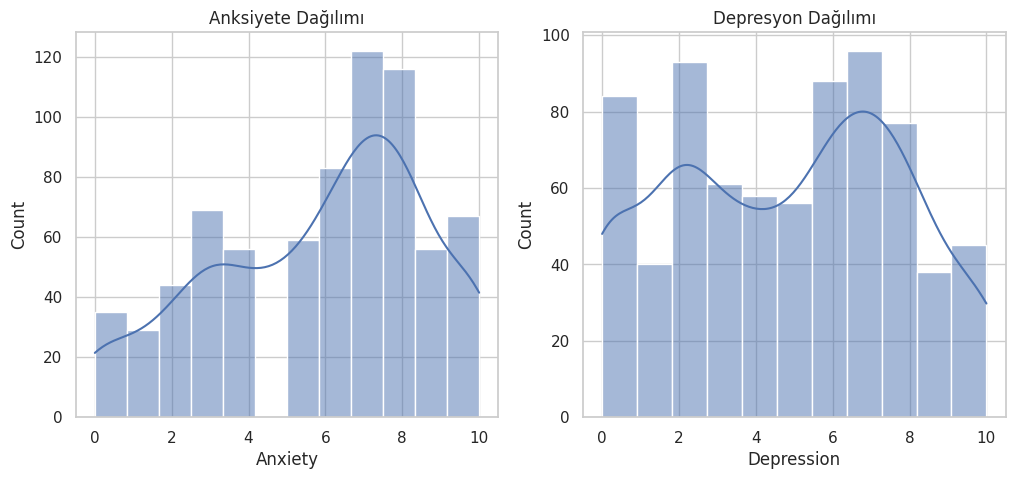

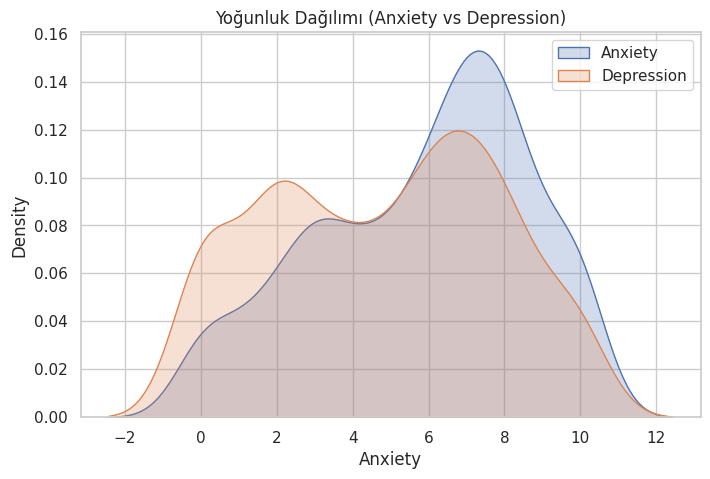

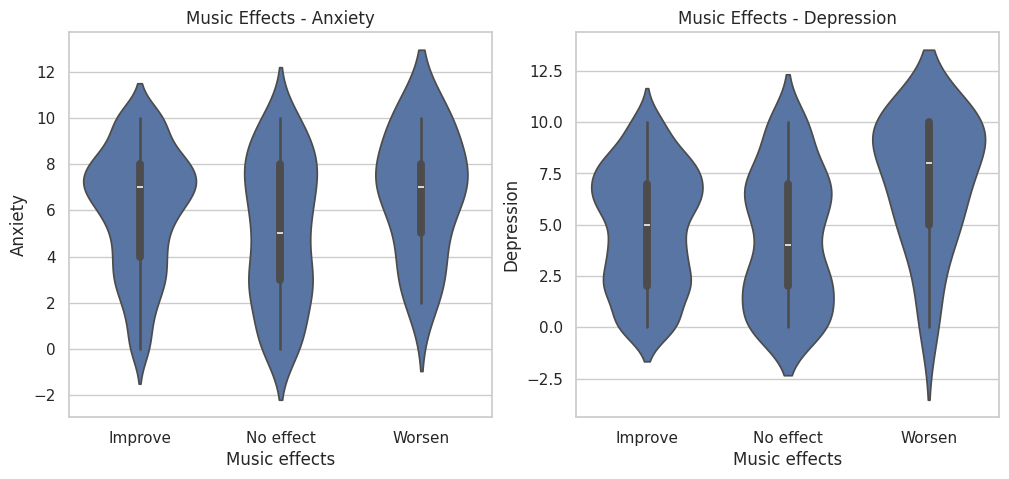

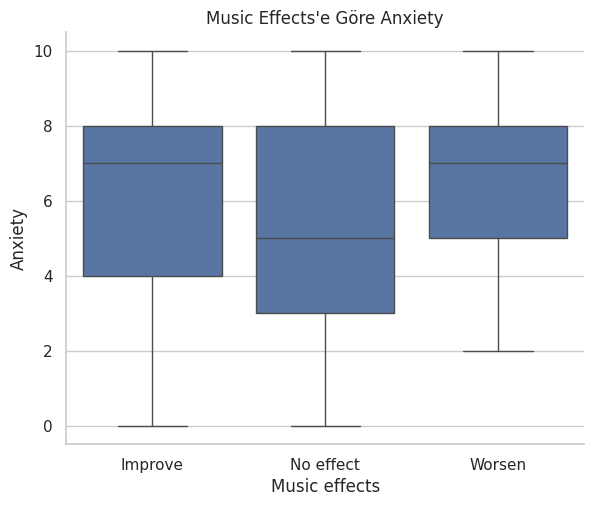

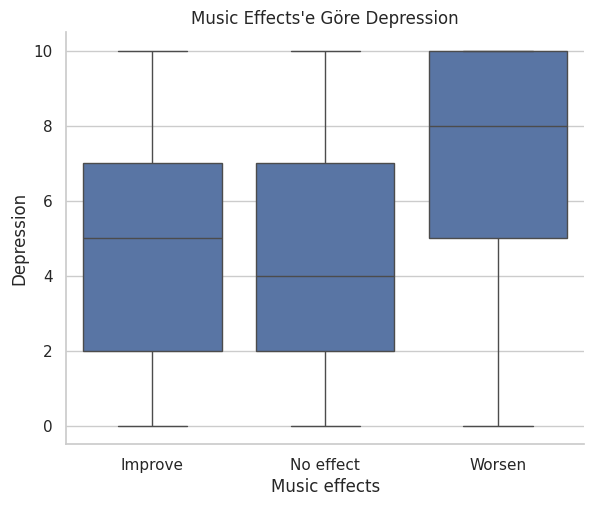

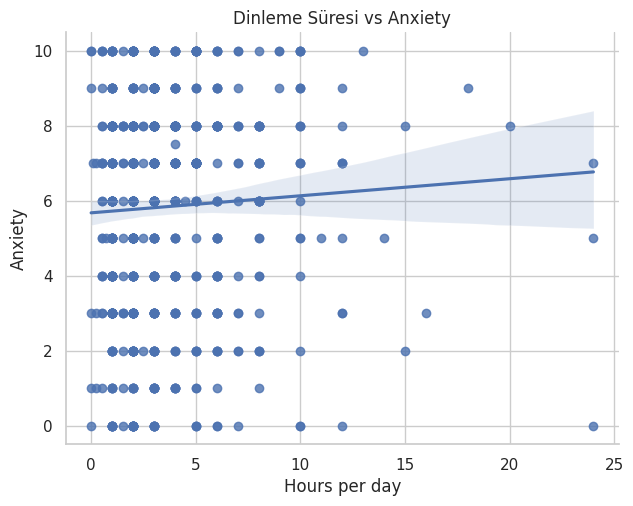

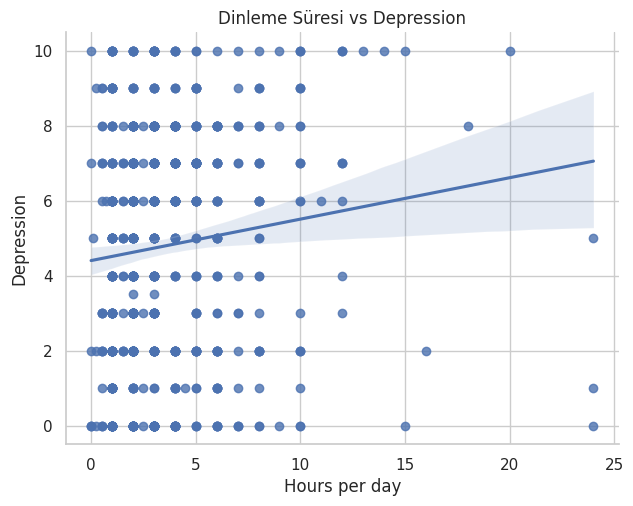

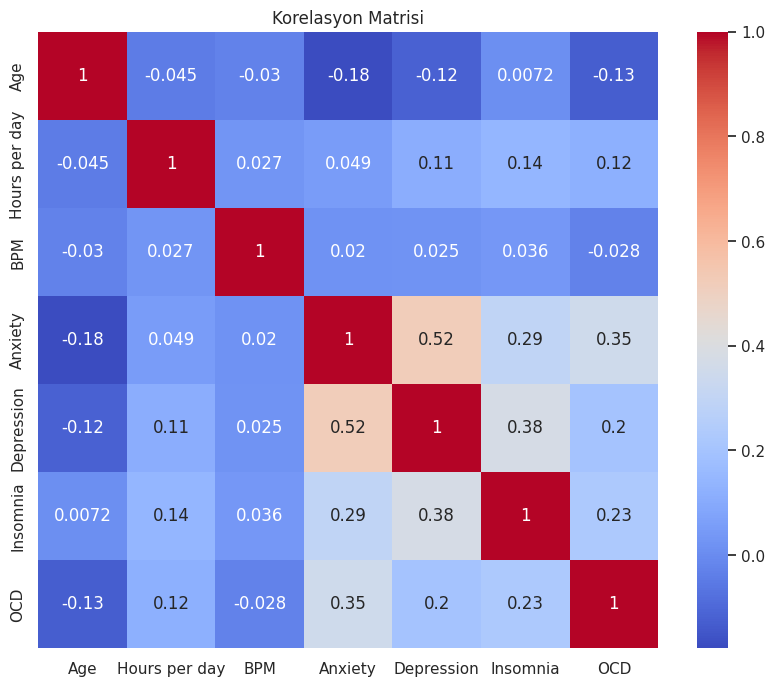

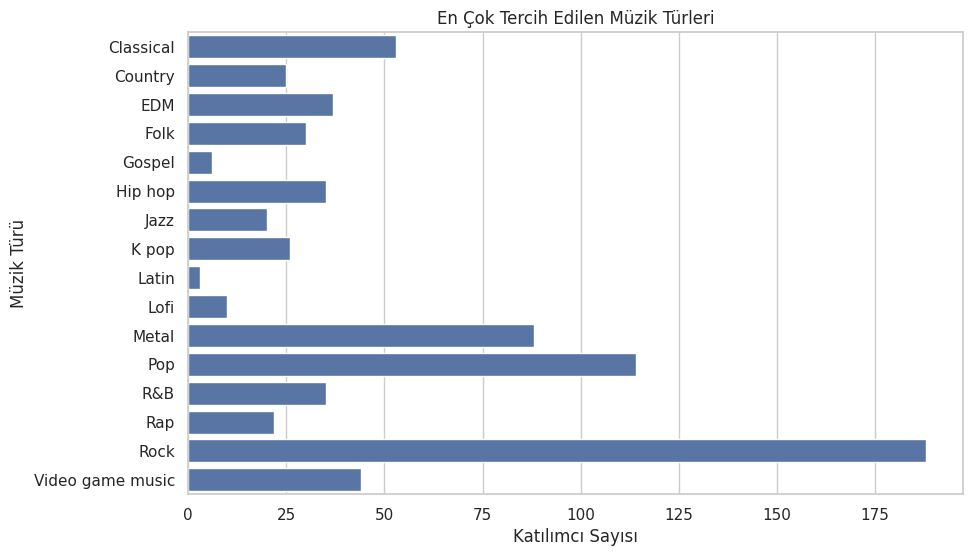

In [21]:
# EK GÖRSELLEŞTİRMELER (EDA)
# Temizlenmiş veri (df_cleaned) kullanılmaktadır.


# KATEGORİK DÖNÜŞÜM (object → category)
for col in df_cleaned.select_dtypes(include='object').columns:
    df_cleaned[col] = df_cleaned[col].astype('category')


import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# 1. PAIRPLOT
# Tüm sayısal değişkenler arası ilişkileri gösterir
selected_cols = ['Age', 'Hours per day', 'BPM', 'Anxiety', 'Depression', 'Insomnia', 'OCD']

sns.pairplot(df_cleaned[selected_cols])
plt.suptitle("Sayısal Değişkenler Arası İlişkiler", y=1.02)
plt.show()

# 2. HISTOGRAM + KDE (Anxiety & Depression)
# Dağılım analizi
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df_cleaned['Anxiety'], kde=True)
plt.title("Anksiyete Dağılımı")

plt.subplot(1,2,2)
sns.histplot(df_cleaned['Depression'], kde=True)
plt.title("Depresyon Dağılımı")

plt.show()

# 3. KDE (YOĞUNLUK ANALİZİ)
plt.figure(figsize=(8,5))
sns.kdeplot(df_cleaned['Anxiety'], label='Anxiety', fill=True)
sns.kdeplot(df_cleaned['Depression'], label='Depression', fill=True)
plt.legend()
plt.title("Yoğunluk Dağılımı (Anxiety vs Depression)")
plt.show()

# 4. VIOLIN PLOT
# Music effects'e göre Anxiety & Depression
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.violinplot(data=df_cleaned, x='Music effects', y='Anxiety')
plt.title("Music Effects - Anxiety")

plt.subplot(1,2,2)
sns.violinplot(data=df_cleaned, x='Music effects', y='Depression')
plt.title("Music Effects - Depression")

plt.show()

# 5. CATPLOT (BOXPLOT)
# Kategorik karşılaştırma
sns.catplot(data=df_cleaned, x='Music effects', y='Anxiety', kind='box', height=5, aspect=1.2)
plt.title("Music Effects'e Göre Anxiety")
plt.show()

sns.catplot(data=df_cleaned, x='Music effects', y='Depression', kind='box', height=5, aspect=1.2)
plt.title("Music Effects'e Göre Depression")
plt.show()

# 6. SCATTER + REGRESYON (LM PLOT)
sns.lmplot(data=df_cleaned, x='Hours per day', y='Anxiety', height=5, aspect=1.3)
plt.title("Dinleme Süresi vs Anxiety")
plt.show()

sns.lmplot(data=df_cleaned, x='Hours per day', y='Depression', height=5, aspect=1.3)
plt.title("Dinleme Süresi vs Depression")
plt.show()

# 7. HEATMAP (KORELASYON)
plt.figure(figsize=(10,8))
sns.heatmap(df_cleaned[selected_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Korelasyon Matrisi")
plt.show()

# 8. MÜZİK TÜRÜ FREKANS GRAFİĞİ
plt.figure(figsize=(10,6))
genre_counts = df_cleaned['Fav genre'].value_counts()

sns.barplot(x=genre_counts.values, y=genre_counts.index)
plt.title("En Çok Tercih Edilen Müzik Türleri")
plt.xlabel("Katılımcı Sayısı")
plt.ylabel("Müzik Türü")
plt.show()

Aşağıda modelleme için veri hazırlama işlemleri gerçekleştirilmiştir. Hedef değişken olan “Music effects” kategorik yapıdan sayısal forma dönüştürülmüş, analizde kullanılacak özellikler belirlenmiştir. Veri seti, model performansını objektif değerlendirebilmek amacıyla eğitim (%80) ve test (%20) olarak ikiye ayrılmıştır. Ayrıca, farklı ölçeklerdeki değişkenlerin modele olumsuz etkisini önlemek için veriler standartlaştırılmıştır. Bu sayede makine öğrenmesi algoritmaları için uygun bir veri yapısı elde edilmiştir.


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Hedef ve Özelliklerin Hazırlanması (Senin df_cleaned verini kullanıyoruz)
le = LabelEncoder()
y = le.fit_transform(df_cleaned['Music effects'])
features = ['Age', 'Hours per day', 'BPM', 'Anxiety', 'Depression', 'Insomnia', 'OCD']
X = df_cleaned[features]

# 2. Veri Sızıntısını Önlemek İçin Bölme (Tüm modeller bu X_train/X_test'i kullanacak)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Ölçeklendirme (Her model için taze kopyalar oluşturacağız)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Veri hazırlandı. Modeller için bekliyor...")

✅ Veri hazırlandı. Modeller için bekliyor...


Aşağıda, veri seti üzerinde Lojistik Regresyon algoritması uygulanmıştır. Model performansını artırmak amacıyla GridSearchCV yöntemi kullanılarak en uygun hiperparametreler belirlenmiştir. Eğitilen model, test veri seti üzerinde değerlendirilmiş ve doğruluk (accuracy) metriği ile performansı ölçülmüştür. Ayrıca modelin sınıflandırma başarısını daha detaylı incelemek için karmaşıklık matrisi (confusion matrix) görselleştirilmiştir.

--- LOJİSTİK REGRESYON BAŞLADI ---
En İyi Parametreler: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Test Doğruluğu: 0.7500


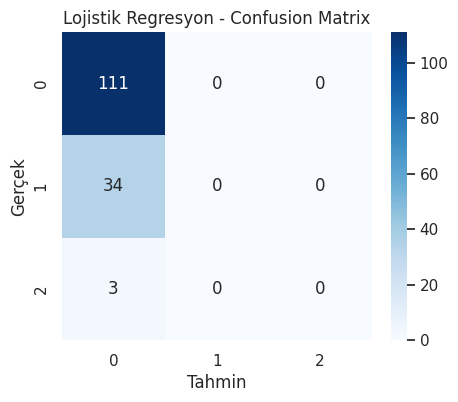

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("--- LOJİSTİK REGRESYON BAŞLADI ---")
lr_params = {'C': [0.01, 0.1, 1, 10], 'penalty': ['l2'], 'solver': ['lbfgs']}
lr_grid = GridSearchCV(LogisticRegression(max_iter=1000), lr_params, cv=5)
lr_grid.fit(X_train_scaled, y_train)

best_lr = lr_grid.best_estimator_
lr_pred = best_lr.predict(X_test_scaled)
lr_acc = accuracy_score(y_test, lr_pred)

print(f"En İyi Parametreler: {lr_grid.best_params_}")
print(f"Test Doğruluğu: {lr_acc:.4f}")

# Confusion Matrix Görselleştirme
cm_lr = confusion_matrix(y_test, lr_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title('Lojistik Regresyon - Confusion Matrix')
plt.xlabel('Tahmin')
plt.ylabel('Gerçek')
plt.show()

Aşağıda, veri seti üzerinde Karar Ağacı (Decision Tree) algoritması uygulanmıştır. Modelin en iyi performansı göstermesi için GridSearchCV yöntemi ile hiperparametre optimizasyonu yapılmıştır. Eğitilen model, test veri seti üzerinde değerlendirilmiş ve doğruluk (accuracy) metriği ile performansı ölçülmüştür. Ayrıca modelin sınıflandırma başarısını detaylı incelemek amacıyla karmaşıklık matrisi (confusion matrix) görselleştirilmiştir.

--- KARAR AĞACI BAŞLADI ---
En İyi Parametreler: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 2}
Test Doğruluğu: 0.7500


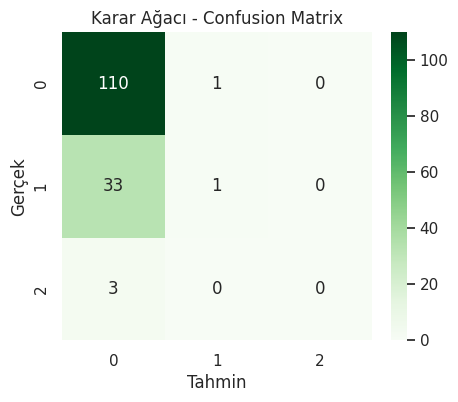

In [24]:
from sklearn.tree import DecisionTreeClassifier

print("--- KARAR AĞACI BAŞLADI ---")
dt_params = {'max_depth': [3, 5, 7, 10], 'min_samples_leaf': [2, 5, 10], 'criterion': ['gini', 'entropy']}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params, cv=5)
dt_grid.fit(X_train_scaled, y_train)

best_dt = dt_grid.best_estimator_
dt_pred = best_dt.predict(X_test_scaled)
dt_acc = accuracy_score(y_test, dt_pred)

print(f"En İyi Parametreler: {dt_grid.best_params_}")
print(f"Test Doğruluğu: {dt_acc:.4f}")

# Confusion Matrix Görselleştirme
cm_dt = confusion_matrix(y_test, dt_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens')
plt.title('Karar Ağacı - Confusion Matrix')
plt.xlabel('Tahmin')
plt.ylabel('Gerçek')
plt.show()

Aşağıda, veri seti üzerinde Random Forest algoritması uygulanmıştır. Model performansını artırmak amacıyla GridSearchCV yöntemi ile hiperparametre optimizasyonu gerçekleştirilmiştir. Eğitilen model, test veri seti üzerinde değerlendirilmiş ve doğruluk (accuracy) metriği ile ölçülmüştür. Elde edilen sonuçlara göre Random Forest modeli, diğer algoritmalara kıyasla daha yüksek performans göstererek en başarılı model olarak belirlenmiştir. Modelin sınıflandırma başarısı, karmaşıklık matrisi (confusion matrix) ile detaylı olarak analiz edilmiştir.

--- RANDOM FOREST BAŞLADI ---
En İyi Parametreler: {'max_depth': 8, 'min_samples_split': 10, 'n_estimators': 100}
Test Doğruluğu: 0.7568


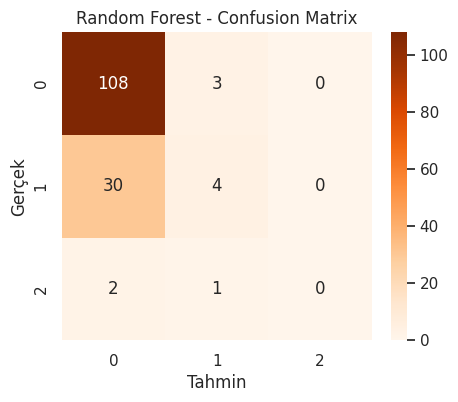

In [25]:
from sklearn.ensemble import RandomForestClassifier

print("--- RANDOM FOREST BAŞLADI ---")
rf_params = {
    'n_estimators': [50, 100],
    'max_depth': [5, 8, 10],
    'min_samples_split': [5, 10]
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5)
rf_grid.fit(X_train_scaled, y_train)

best_rf = rf_grid.best_estimator_
rf_pred = best_rf.predict(X_test_scaled)
rf_acc = accuracy_score(y_test, rf_pred)

print(f"En İyi Parametreler: {rf_grid.best_params_}")
print(f"Test Doğruluğu: {rf_acc:.4f}")

# Confusion Matrix Görselleştirme
cm_rf = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges')
plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Tahmin')
plt.ylabel('Gerçek')
plt.show()

Aşağıda, modellerin performansını daha güvenilir bir şekilde değerlendirmek amacıyla 30 farklı rastgele veri bölmesi (iterasyon) kullanılarak tekrarlı deneyler gerçekleştirilmiştir. Her iterasyonda veri seti yeniden eğitim ve test olarak ayrılmış, modeller yeniden eğitilmiş ve doğruluk değerleri kaydedilmiştir. Elde edilen sonuçlar üzerinden modeller arası performans farkını incelemek için istatistiksel testler uygulanmıştır. Özellikle Random Forest ve Karar Ağacı modelleri arasında bağımsız örneklem t-testi kullanılarak anlamlılık analizi yapılmıştır. Ayrıca, modellerin doğruluk dağılımları kutu grafiği (boxplot) ile görselleştirilerek performans karşılaştırması desteklenmiştir.

🔄 30 İterasyonlu Simülasyon Başladı...
✅ Simülasyon Tamamlandı.

--- İSTATİSTİKSEL ANALİZ (RF vs DT) ---
T-İstatistiği: 0.6901, P-Değeri: 0.4929
Sonuç: Modeller arasında anlamlı bir fark BULUNAMADI (H0 Reddedilemez).


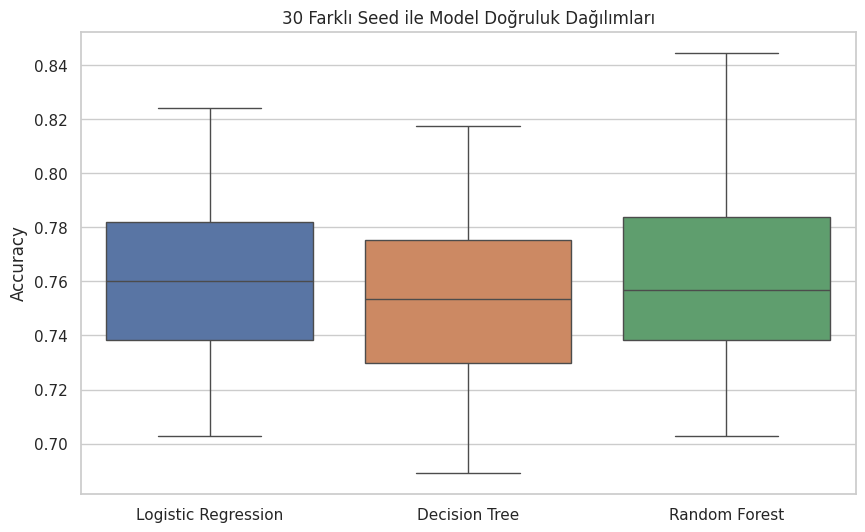

In [26]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from scipy.stats import ttest_ind, wilcoxon

# 1. Verileri toplamak için boş listeler
results_data = {
    'Logistic Regression': [],
    'Decision Tree': [],
    'Random Forest': []
}

print("🔄 30 İterasyonlu Simülasyon Başladı...")

for i in range(30):
    # Her seferinde farklı bir seed ile veriyi bölüyoruz
    X_train_iter, X_test_iter, y_train_iter, y_test_iter = train_test_split(
        X, y, test_size=0.2, random_state=i # i burada seed görevi görüyor
    )

    # Ölçeklendirme (Her iterasyonda veriye göre yeniden fit edilmeli)
    # sc.fit_transform(X_train_iter) vb. işlemlerini burada yapmalısın
    X_train_scaled_iter = scaler.fit_transform(X_train_iter)
    X_test_scaled_iter = scaler.transform(X_test_iter)

    # Lojistik Regresyon
    lr_iter = LogisticRegression(max_iter=1000, **lr_grid.best_params_)
    lr_iter.fit(X_train_scaled_iter, y_train_iter)
    results_data['Logistic Regression'].append(lr_iter.score(X_test_scaled_iter, y_test_iter))

    # Karar Ağacı
    dt_iter = DecisionTreeClassifier(**dt_grid.best_params_)
    dt_iter.fit(X_train_scaled_iter, y_train_iter)
    results_data['Decision Tree'].append(dt_iter.score(X_test_scaled_iter, y_test_iter))

    # Random Forest
    rf_iter = RandomForestClassifier(**rf_grid.best_params_)
    rf_iter.fit(X_train_scaled_iter, y_train_iter)
    results_data['Random Forest'].append(rf_iter.score(X_test_scaled_iter, y_test_iter))

print("✅ Simülasyon Tamamlandı.")

# 2. İstatistiksel Kıyaslama (Örn: RF vs DT)
# H0: İki model arasında performans farkı yoktur.
t_stat, p_val = ttest_ind(results_data['Random Forest'], results_data['Decision Tree'])

print("\n--- İSTATİSTİKSEL ANALİZ (RF vs DT) ---")
print(f"T-İstatistiği: {t_stat:.4f}, P-Değeri: {p_val:.4f}")

alpha = 0.05
if p_val < alpha:
    print("Sonuç: Modeller arasındaki fark istatistiksel olarak ANLAMLI (H0 Red).")
else:
    print("Sonuç: Modeller arasında anlamlı bir fark BULUNAMADI (H0 Reddedilemez).")

# 3. Sonuçların Görselleştirilmesi (Boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=pd.DataFrame(results_data))
plt.title("30 Farklı Seed ile Model Doğruluk Dağılımları")
plt.ylabel("Accuracy")
plt.show()

Aşağıda , modellerin performansını farklı veri bölmeleri üzerinde değerlendirmek amacıyla rastgele tohum (seed) değerleri oluşturulmuştur. Belirlenen geniş bir seed havuzundan rastgele 30 farklı seed seçilerek her iterasyonda veri setinin farklı şekilde bölünmesi sağlanmıştır. Bu sayede modellerin genelleme yeteneği daha güvenilir bir şekilde analiz edilmiştir. Ayrıca, her modelin doğruluk değerlerini saklamak için uygun veri yapıları oluşturulmuştur.

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from statsmodels.stats.contingency_tables import mcnemar

# Seed havuzu
all_seeds = np.arange(10**3)
# Analiz için bu havuzdan 30 tane rastgele seed seçiyoruz
np.random.seed(42) # Seçimin her seferinde aynı olması için
selected_seeds = np.random.choice(all_seeds, 30, replace=False)

# Skorları saklamak için sözlük
model_scores = {'LR': [], 'DT': [], 'RF': []}

Aşağıda, Lojistik Regresyon modeli 30 farklı rastgele seed değeri kullanılarak tekrarlı olarak eğitilmiş ve test edilmiştir. Her iterasyonda veri seti yeniden eğitim ve test olarak ayrılmış, ardından veriler standartlaştırılarak modele uygun hale getirilmiştir. Model performansı her iterasyonda hesaplanarak doğruluk değerleri kaydedilmiştir. Son olarak, modelin sınıflandırma başarısını görselleştirmek amacıyla son iterasyona ait karmaşıklık matrisi (confusion matrix) oluşturulmuştur.

--- LOJİSTİK REGRESYON (30 SEED) BAŞLADI ---


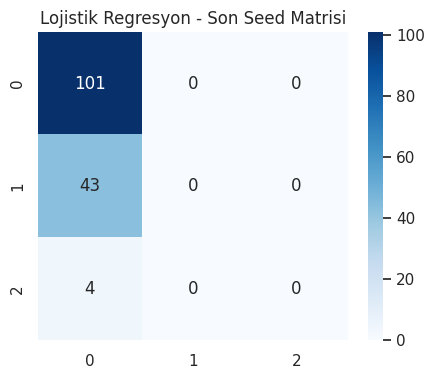

In [28]:
from sklearn.preprocessing import StandardScaler

# Ölçeklendiriciyi döngü dışında tanımlıyoruz
scaler = StandardScaler()

print("--- LOJİSTİK REGRESYON (30 SEED) BAŞLADI ---")
for s in selected_seeds:
    # 1. Veriyi bölüyoruz
    X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(X, y, test_size=0.2, random_state=s)

    # 2. ÖLÇEKLENDİRME (Hata buradaydı, şimdi tanımladık)
    X_train_scaled_i = scaler.fit_transform(X_train_i)
    X_test_scaled_i = scaler.transform(X_test_i)

    # 3. Model Eğitimi
    model = LogisticRegression(max_iter=1000, **lr_grid.best_params_)
    model.fit(X_train_scaled_i, y_train_i)

    # 4. Skoru kaydet
    model_scores['LR'].append(model.score(X_test_scaled_i, y_test_i))

# Matris çizimi
y_pred_lr = model.predict(X_test_scaled_i)
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test_i, y_pred_lr), annot=True, fmt='d', cmap='Blues')
plt.title("Lojistik Regresyon - Son Seed Matrisi")
plt.show()

Aşağıda, Karar Ağacı modeli 30 farklı rastgele seed değeri kullanılarak tekrarlı şekilde eğitilmiş ve test edilmiştir. Her iterasyonda veri seti yeniden bölünmüş ve model, GridSearchCV ile elde edilen en iyi hiperparametreler kullanılarak eğitilmiştir. Her iterasyonda elde edilen doğruluk değerleri kaydedilerek modelin performansının tutarlılığı analiz edilmiştir. Ayrıca, modelin sınıflandırma başarısını incelemek amacıyla son iterasyona ait karmaşıklık matrisi görselleştirilmiştir.

--- KARAR AĞACI (30 SEED) BAŞLADI ---


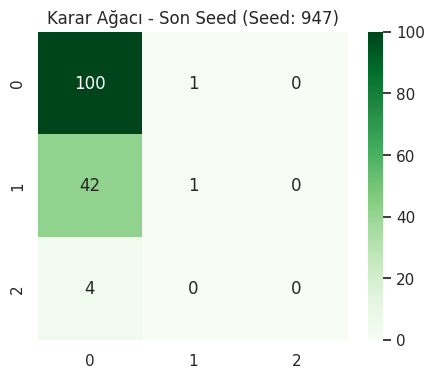

In [29]:
print("--- KARAR AĞACI (30 SEED) BAŞLADI ---")
for s in selected_seeds:
    # Veriyi böl
    X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(X, y, test_size=0.2, random_state=s)

    # Ölçeklendir
    X_train_scaled_i = scaler.fit_transform(X_train_i)
    X_test_scaled_i = scaler.transform(X_test_i)

    # Model eğitimi (GridSearch'ten gelen en iyi parametrelerle)
    model_dt = DecisionTreeClassifier(**dt_grid.best_params_)
    model_dt.fit(X_train_scaled_i, y_train_i)

    # Skoru listeye ekle
    model_scores['DT'].append(model_dt.score(X_test_scaled_i, y_test_i))

# Sonuçları görselleştir (Son seed için)
y_pred_dt = model_dt.predict(X_test_scaled_i)
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test_i, y_pred_dt), annot=True, fmt='d', cmap='Greens')
plt.title(f"Karar Ağacı - Son Seed (Seed: {s})")
plt.show()

Aşağıda, Random Forest modeli 30 farklı rastgele seed değeri kullanılarak tekrarlı şekilde eğitilmiş ve test edilmiştir. Her iterasyonda veri seti yeniden bölünmüş ve model, GridSearchCV ile belirlenen en iyi hiperparametreler kullanılarak eğitilmiştir. Elde edilen doğruluk değerleri kaydedilerek modelin performans tutarlılığı analiz edilmiştir. Sonuçlar, Random Forest modelinin farklı veri bölmelerinde de yüksek ve stabil performans sergilediğini göstermektedir. Ayrıca, modelin sınıflandırma başarısını detaylı incelemek amacıyla son iterasyona ait karmaşıklık matrisi görselleştirilmiştir.

--- RANDOM FOREST (30 SEED) BAŞLADI ---


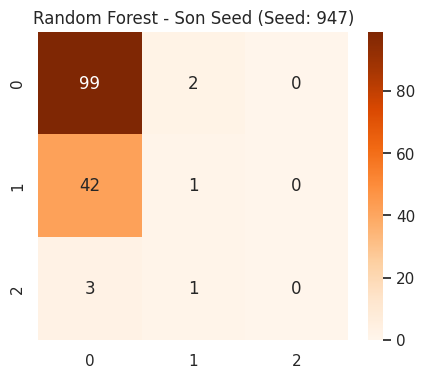

In [30]:
print("--- RANDOM FOREST (30 SEED) BAŞLADI ---")
for s in selected_seeds:
    # Veriyi böl
    X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(X, y, test_size=0.2, random_state=s)

    # Ölçeklendir
    X_train_scaled_i = scaler.fit_transform(X_train_i)
    X_test_scaled_i = scaler.transform(X_test_i)

    # Model eğitimi
    model_rf = RandomForestClassifier(**rf_grid.best_params_)
    model_rf.fit(X_train_scaled_i, y_train_i)

    # Skoru listeye ekle
    model_scores['RF'].append(model_rf.score(X_test_scaled_i, y_test_i))

# Sonuçları görselleştir (Son seed için)
y_pred_rf = model_rf.predict(X_test_scaled_i)
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test_i, y_pred_rf), annot=True, fmt='d', cmap='Oranges')
plt.title(f"Random Forest - Son Seed (Seed: {s})")
plt.show()

Aşağıda, 30 farklı veri bölmesi üzerinden elde edilen model performansları karşılaştırılmıştır. Modellerin doğruluk değerleri kutu grafiği (boxplot) ile görselleştirilerek dağılım, medyan ve varyasyonları analiz edilmiştir. Ayrıca, her modele ait ortalama, standart sapma, minimum ve maksimum doğruluk değerleri hesaplanarak istatistiksel özet sunulmuştur. Bu analiz sayesinde modellerin performans kararlılığı ve genelleme yetenekleri değerlendirilmiştir.

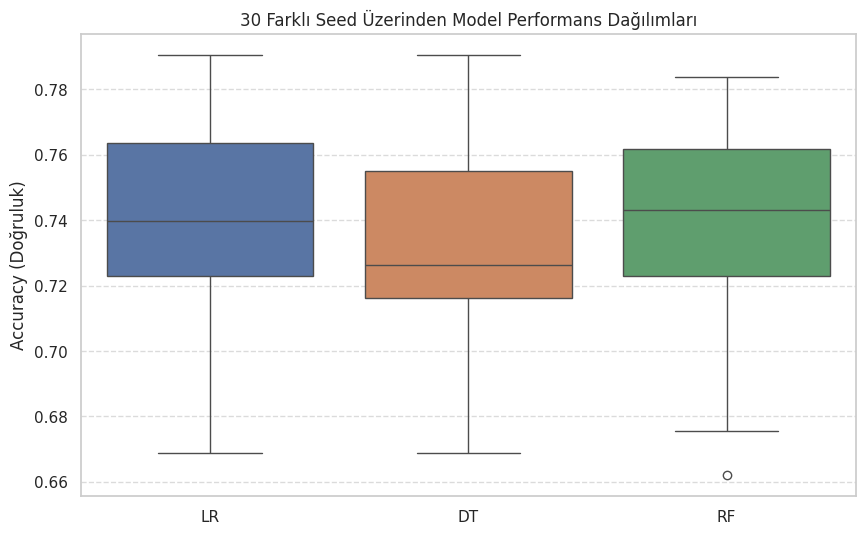


--- 30 DENEME SONUCU ÖZETİ ---
            LR        DT        RF
mean  0.738964  0.729730  0.738739
std   0.033124  0.034407  0.032686
min   0.668919  0.668919  0.662162
max   0.790541  0.790541  0.783784


In [31]:
plt.figure(figsize=(10,6))
df_results = pd.DataFrame(model_scores)
sns.boxplot(data=df_results)
plt.title("30 Farklı Seed Üzerinden Model Performans Dağılımları")
plt.ylabel("Accuracy (Doğruluk)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# İstatistiksel özet
print("\n--- 30 DENEME SONUCU ÖZETİ ---")
print(df_results.describe().loc[['mean', 'std', 'min', 'max']])